In [1]:
# Always import phasic first to set jax backend correctly
import phasic
import numpy as np
np.random.seed(42)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('retina', 'png')
import matplotlib
matplotlib.rcParams['figure.figsize'] = (5, 3.7)
sns.set_context('paper', font_scale=0.9)
# import warnings
# warnings.filterwarnings(action='ignore', category=Warning, module='seaborn')
phasic.set_theme('dark')

In [2]:
from phasic.state_indexing import Property, StateIndexer

# Two-Locus ARG on Two-Island Model

This notebook combines:
- **Two-locus ARG**: Lineages track descendants at two loci, with coalescence and recombination
- **Two-island model**: Two populations exchange migrants

State space tracks:
- `descendants_l1`: Number of descendants at locus 1
- `descendants_l2`: Number of descendants at locus 2  
- `population`: Which island (0 or 1)

Events:
- **Coalescence**: Lineages in the same population merge
- **Recombination**: Lineage splits by locus
- **Migration**: Lineage moves between populations

**Note**: This is an illustrative implementation. For a complete version, see `two_locus_two_island.ipynb` in this directory.

## Graph Construction

In [3]:
def two_locus_two_island_arg(s=None, N=None, R=None, m12=None, m21=None):
    """
    Build two-locus ARG on two-island model.
    
    Parameters
    ----------
    s : int
        Sample size (per population)
    N : float
        Effective population size (diploid, same for both populations)
    R : float
        Recombination rate between loci
    m12 : float
        Migration rate from population 0 to population 1
    m21 : float
        Migration rate from population 1 to population 0
    
    Returns
    -------
    phasic.Graph
        ARG graph
    """
    # Define state space: two loci + population
    state_space = StateIndexer([
        Property('descendants_l1', max_value=s),
        Property('descendants_l2', max_value=s),
        Property('population', max_value=1)  # 0 or 1
    ])
    
    n = state_space.n_states
    graph = phasic.Graph(n)
    
    # Initial state: all lineages start in population 0 with (1,1) descendants
    initial_state = np.zeros(n, dtype=int)
    initial_idx = state_space.props_to_index(
        descendants_l1=1, 
        descendants_l2=1, 
        population=0
    )
    initial_state[initial_idx] = s
    
    first_vertex = graph.find_or_create_vertex(initial_state)
    graph.starting_vertex().add_edge(first_vertex, 1.0)
    
    # Build graph iteratively
    index = 1
    while index < graph.vertices_length():
        vertex = graph.vertex_at(index)
        state = vertex.state()
        
        total_lineages = int(np.sum(state))
        if total_lineages <= 1:
            index += 1
            continue
        
        # Iterate over all configurations
        for i in range(n):
            if state[i] == 0:
                continue
            
            conf_i = state_space.index_to_props(i)
            pop_i = conf_i['population']
            
            # MIGRATION
            if conf_i['descendants_l1'] > 0 or conf_i['descendants_l2'] > 0:
                # Migrate to other population
                new_pop = 1 - pop_i
                migration_rate = m12 if pop_i == 0 else m21
                
                child_state = state.copy()
                child_state[i] -= 1
                
                k = state_space.props_to_index(
                    descendants_l1=conf_i['descendants_l1'],
                    descendants_l2=conf_i['descendants_l2'],
                    population=new_pop
                )
                child_state[k] += 1
                
                child_vertex = graph.find_or_create_vertex(child_state)
                vertex.add_edge(child_vertex, migration_rate * state[i])
            
            # COALESCENCE (only within same population)
            for j in range(i, n):
                if state[j] == 0:
                    continue
                
                conf_j = state_space.index_to_props(j)
                
                # Must be in same population
                if conf_j['population'] != pop_i:
                    continue
                
                # Calculate coalescence rate
                if i == j:
                    if state[i] < 2:
                        continue
                    rate = state[i] * (state[i] - 1) / 2 / N
                else:
                    if state[i] < 1 or state[j] < 1:
                        continue
                    rate = state[i] * state[j] / N
                
                # Create child state
                child_state = state.copy()
                child_state[i] -= 1
                child_state[j] -= 1
                
                # Add coalesced lineage
                new_l1 = conf_i['descendants_l1'] + conf_j['descendants_l1']
                new_l2 = conf_i['descendants_l2'] + conf_j['descendants_l2']
                
                if new_l1 <= s and new_l2 <= s:
                    k = state_space.props_to_index(
                        descendants_l1=new_l1,
                        descendants_l2=new_l2,
                        population=pop_i
                    )
                    child_state[k] += 1
                    
                    child_vertex = graph.find_or_create_vertex(child_state)
                    vertex.add_edge(child_vertex, rate)
            
            # RECOMBINATION
            if (state[i] > 0 and 
                conf_i['descendants_l1'] > 0 and 
                conf_i['descendants_l2'] > 0):
                
                child_state = state.copy()
                child_state[i] -= 1
                
                # Add two recombinant lineages
                k = state_space.props_to_index(
                    descendants_l1=conf_i['descendants_l1'],
                    descendants_l2=0,
                    population=pop_i
                )
                l = state_space.props_to_index(
                    descendants_l1=0,
                    descendants_l2=conf_i['descendants_l2'],
                    population=pop_i
                )
                child_state[k] += 1
                child_state[l] += 1
                
                child_vertex = graph.find_or_create_vertex(child_state)
                vertex.add_edge(child_vertex, R)
        
        index += 1
    
    return graph

## Example

In [4]:
# Build small example
graph = two_locus_two_island_arg(
    s=2,           # 2 samples per population
    N=1000,        # Population size
    R=1.0,         # Recombination rate
    m12=0.1,       # Migration pop 0 -> 1
    m21=0.1        # Migration pop 1 -> 0
)

print(f"Graph has {graph.vertices_length()} vertices")

Graph has 47 vertices


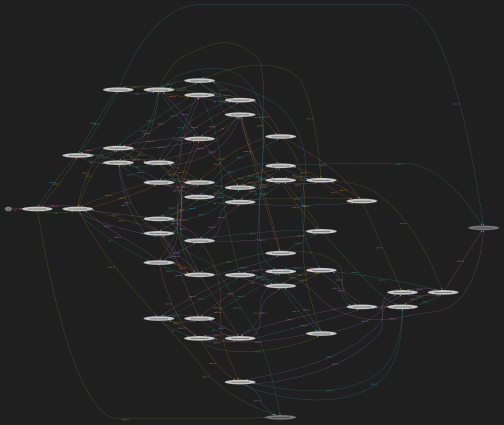

In [5]:
# Visualize (limit nodes for clarity)
graph.plot(max_nodes=100)

## Analysis

In [7]:
# Expected TMRCA
first_moment, second_moment = graph.moments(2)
expectation = first_moment
print(f"E[TMRCA] = {expectation:.4f}")

# Variance
variance = second_moment - first_moment**2
print(f"Var[TMRCA] = {variance:.4f}")

E[TMRCA] = 4999.2026
Var[TMRCA] = 9036088.7909


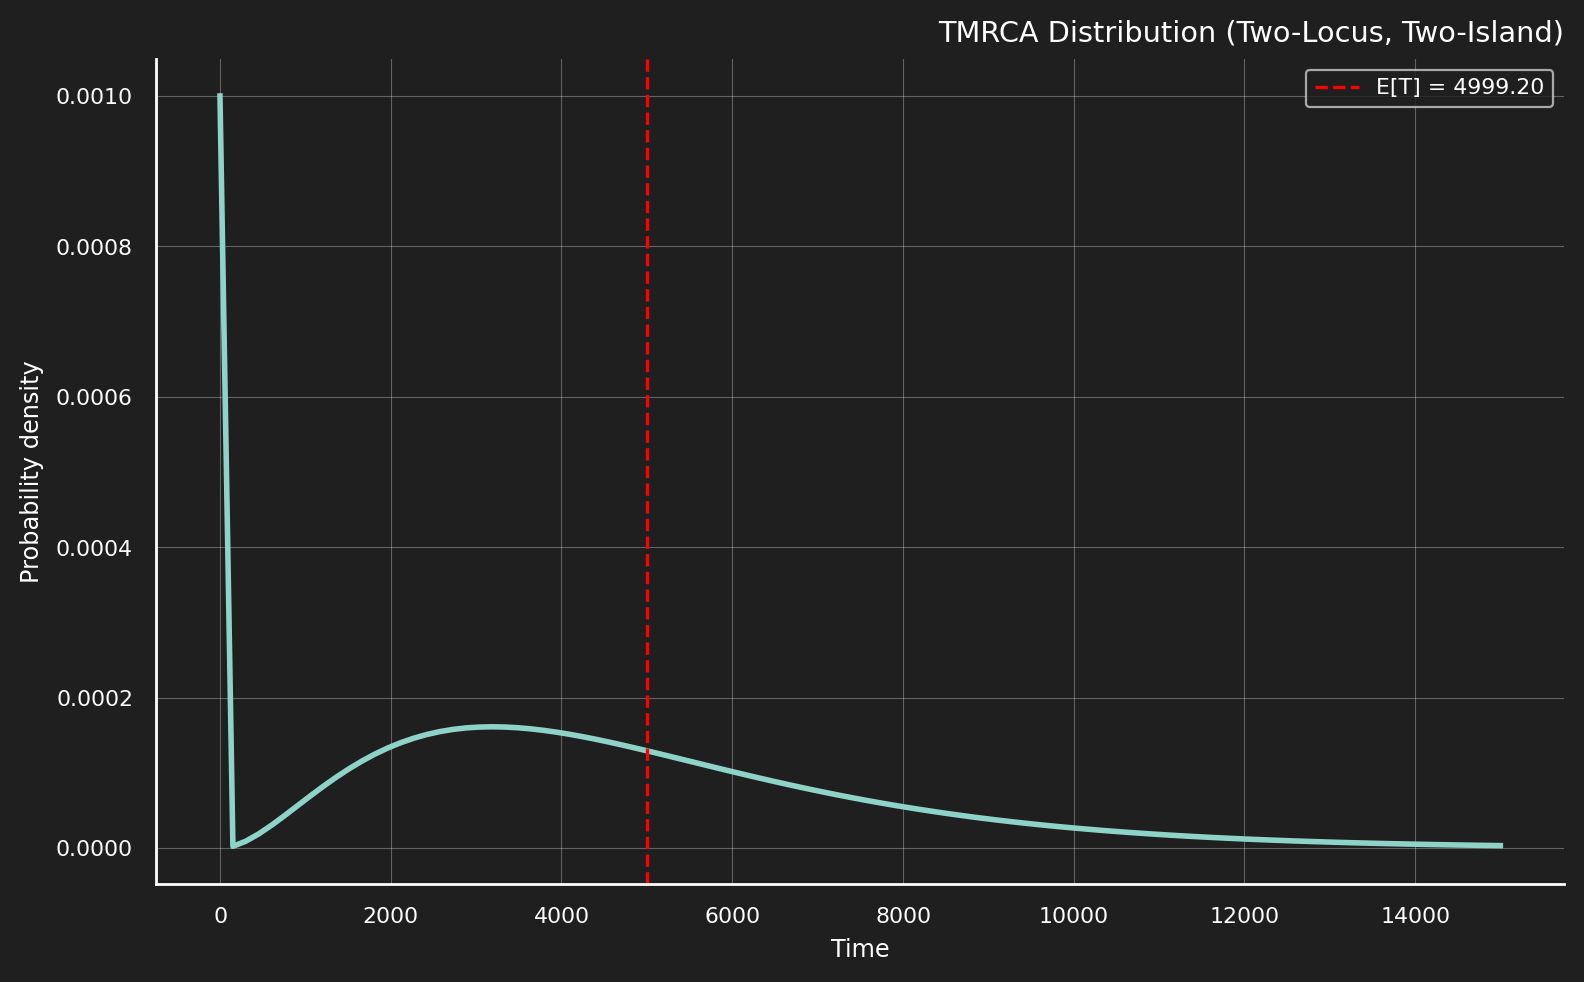

In [8]:
# Plot TMRCA distribution
times = np.linspace(0, expectation * 3, 100)
pdf = graph.pdf(times)

plt.figure(figsize=(8, 5))
plt.plot(times, pdf, linewidth=2)
plt.axvline(expectation, color='r', linestyle='--', 
            label=f'E[T] = {expectation:.2f}')
plt.xlabel('Time')
plt.ylabel('Probability density')
plt.title('TMRCA Distribution (Two-Locus, Two-Island)')
plt.legend()
plt.tight_layout()
sns.despine()
plt.show()

## Effect of Migration Rate

In [10]:
# Compare different migration rates
migration_rates = [0.01, 0.1, 1.0]
results = []

for m in migration_rates:
    g = two_locus_two_island_arg(s=2, N=1000, R=1.0, m12=m, m21=m)
    exp_t = g.expectation()
    results.append({
        'migration_rate': m,
        'vertices': g.vertices_length(),
        'E[TMRCA]': exp_t
    })

df = pd.DataFrame(results)
print("\nEffect of migration rate:")
print(df.to_string(index=False))


Effect of migration rate:
 migration_rate  vertices    E[TMRCA]
           0.01        47 5032.163726
           0.10        47 4999.202566
           1.00        47 4996.874476


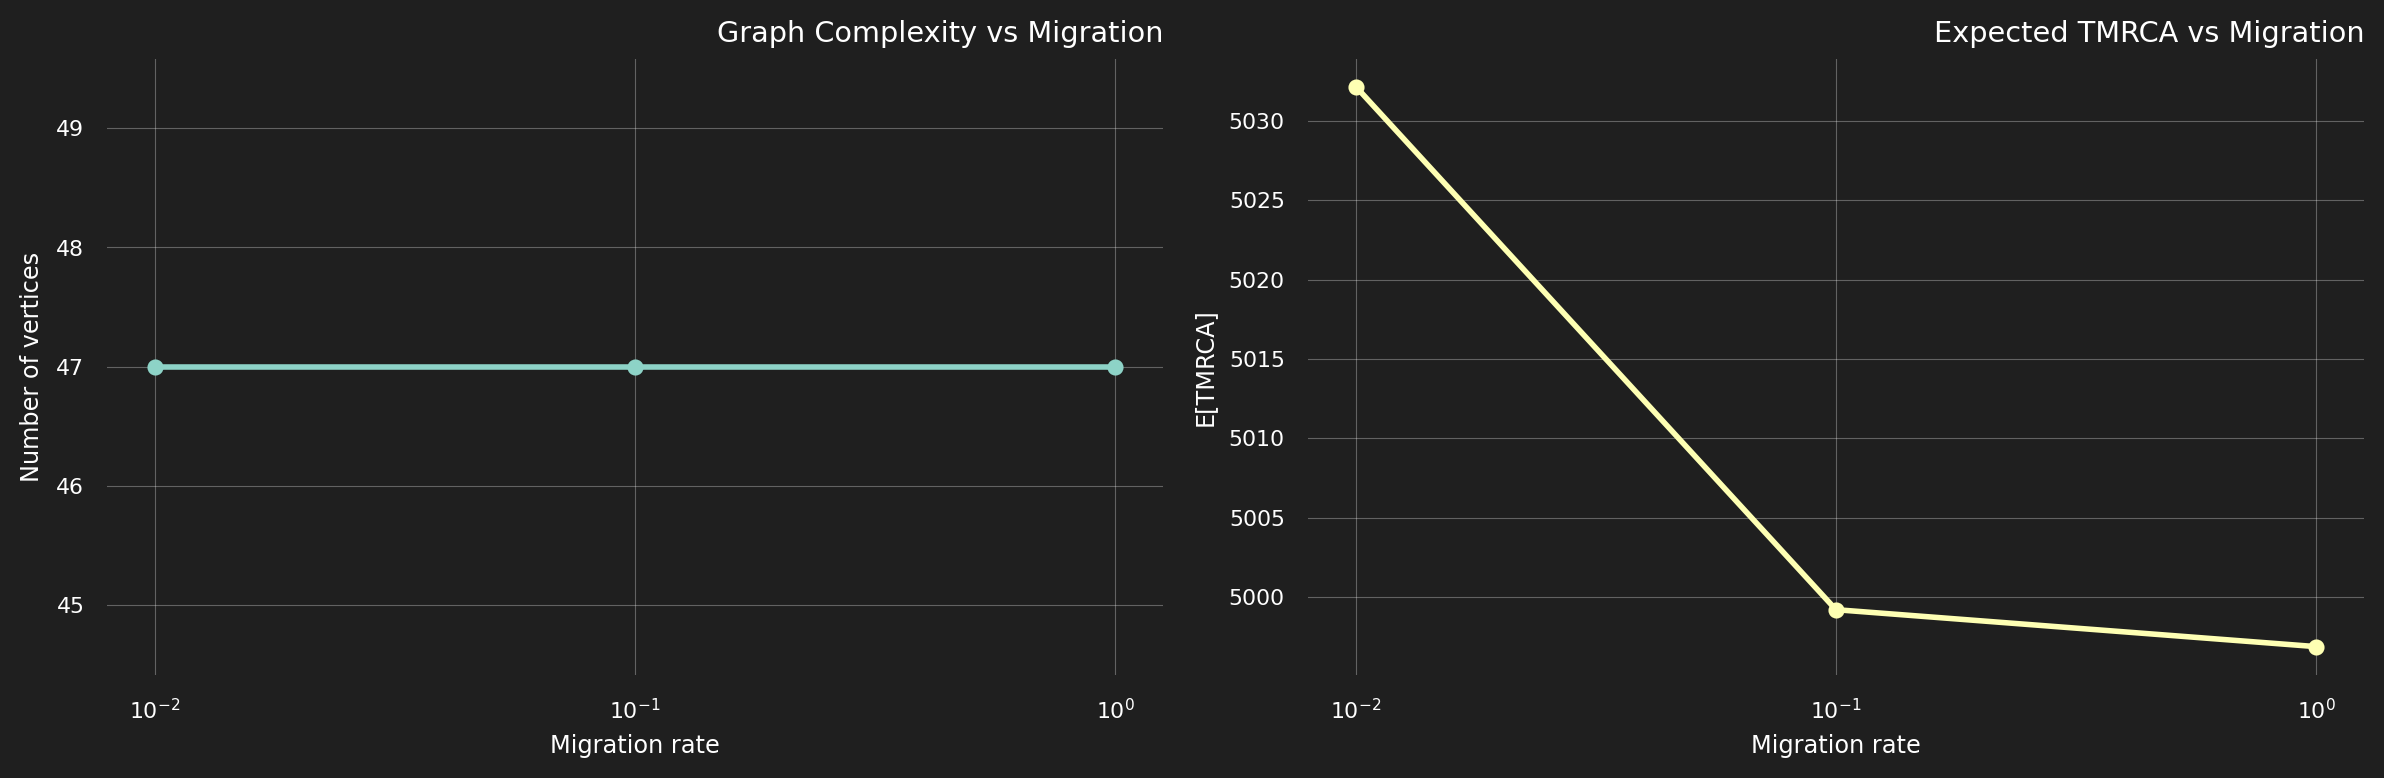

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot graph size
axes[0].plot(df['migration_rate'], df['vertices'], marker='o', linewidth=2)
axes[0].set_xlabel('Migration rate')
axes[0].set_ylabel('Number of vertices')
axes[0].set_title('Graph Complexity vs Migration')
axes[0].set_xscale('log')

# Plot expected TMRCA
axes[1].plot(df['migration_rate'], df['E[TMRCA]'], 
             marker='o', linewidth=2, color='C1')
axes[1].set_xlabel('Migration rate')
axes[1].set_ylabel('E[TMRCA]')
axes[1].set_title('Expected TMRCA vs Migration')
axes[1].set_xscale('log')

plt.tight_layout()
# sns.despine()
# plt.show()

## Summary

This notebook demonstrates:
- Two-locus ARG on structured populations
- Three types of events: coalescence, recombination, migration
- Flexible state indexing for complex models
- Effect of migration on graph complexity and TMRCA

**Key observations:**
- Higher migration rates reduce TMRCA (populations mix faster)
- Graph complexity increases with migration opportunities
- State space grows as product of locus states × population states

**Related notebooks:**
- `two-locus-arg.ipynb`: Two-locus ARG without population structure
- `im_model.ipynb`: Isolation-migration model (single locus)
- `isolation_migration.ipynb`: IM model with split times
- `two_locus_two_island.ipynb`: Complete implementation with additional features